In [ ]:
import pandas as pd

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving epraccur (1).csv to epraccur (1) (1).csv


In [ ]:
gp_data = pd.read_csv(list(uploaded.keys())[0], header=None, dtype=str)

gp_data.head()

,0,1,2,3,4,5,6,7,8,9,...,17,18,19,20,21,22,23,24,25,26
0,A81001,THE DENSHAM SURGERY,Y63,QHM,HEALTH CENTRE,LAWSON STREET,NaN,STOCKTON-ON-TEES,NaN,TS18 1HU,...,01642 672351,NaN,NaN,NaN,1,NaN,16C,NaN,RO76,NaN
1,A81002,QUEENS PARK MEDICAL CENTRE,Y63,QHM,FARRER STREET,NaN,NaN,STOCKTON ON TEES,NaN,TS18 2AW,...,01642 618170,NaN,NaN,NaN,1,NaN,16C,NaN,RO76,NaN
2,A81003,VICTORIA MEDICAL PRACTICE,Y63,QHM,HEALTH CENTRE,VICTORIA ROAD,NaN,HARTLEPOOL,NaN,TS26 8DB,...,01429 272945,NaN,NaN,NaN,1,NaN,00K,NaN,RO76,NaN
3,A81004,ACKLAM MEDICAL CENTRE,Y63,QHM,TRIMDON AVENUE,ACKLAM,NaN,MIDDLESBROUGH,NaN,TS5 8SB,...,01642 827697,NaN,NaN,NaN,1,NaN,16C,NaN,RO76,NaN
4,A81005,SPRINGWOOD SURGERY,Y63,QHM,RECTORY LANE,NaN,NaN,GUISBOROUGH,NaN,TS14 7DJ,...,01287 619611,NaN,NaN,NaN,1,NaN,16C,NaN,RO76,NaN


In [ ]:
gp_data.shape

(15493, 27)

In [ ]:
gp_data.columns = [
    "Practice_Code", "Practice_Name", "Unknown_1", "Unknown_2",
    "Address_1", "Address_2", "Address_3", "Town_City", "County",
    "Postcode", "Open_Date", "Close_Date", "Status",
    "Practice_Type", "ICB_Code", "Join_Date", "Leave_Date",
    "Phone", "Unused_1", "Unused_2", "Unused_3", "Flag",
    "Unused_4", "Prescribing_Setting", "Unused_5", "Region_Code",
    "Extra_Column"
]

gp_clean = gp_data[
    ["Practice_Code", "Practice_Name", "Town_City", "County", "Postcode", "Open_Date", "Close_Date", "Status"]
]

gp_clean.head()

,Practice_Code,Practice_Name,Town_City,County,Postcode,Open_Date,Close_Date,Status
0,A81001,THE DENSHAM SURGERY,STOCKTON-ON-TEES,NaN,TS18 1HU,19740401,NaN,ACTIVE
1,A81002,QUEENS PARK MEDICAL CENTRE,STOCKTON ON TEES,NaN,TS18 2AW,19740401,NaN,ACTIVE
2,A81003,VICTORIA MEDICAL PRACTICE,HARTLEPOOL,NaN,TS26 8DB,19740401,20171031,INACTIVE
3,A81004,ACKLAM MEDICAL CENTRE,MIDDLESBROUGH,NaN,TS5 8SB,19740401,NaN,ACTIVE
4,A81005,SPRINGWOOD SURGERY,GUISBOROUGH,NaN,TS14 7DJ,19740401,NaN,ACTIVE


In [ ]:
gp_clean.shape

(15493, 8)

In [ ]:
# Fix dates
gp_clean["Open_Date"] = pd.to_datetime(gp_clean["Open_Date"])
gp_clean["Close_Date"] = pd.to_datetime(gp_clean["Close_Date"])

# Show data
gp_clean.head()

/tmp/ipykernel_2623/2985717305.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gp_clean["Open_Date"] = pd.to_datetime(gp_clean["Open_Date"])
/tmp/ipykernel_2623/2985717305.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gp_clean["Close_Date"] = pd.to_datetime(gp_clean["Close_Date"])


,Practice_Code,Practice_Name,Town_City,County,Postcode,Open_Date,Close_Date,Status
0,A81001,THE DENSHAM SURGERY,STOCKTON-ON-TEES,NaN,TS18 1HU,1974-04-01,NaT,ACTIVE
1,A81002,QUEENS PARK MEDICAL CENTRE,STOCKTON ON TEES,NaN,TS18 2AW,1974-04-01,NaT,ACTIVE
2,A81003,VICTORIA MEDICAL PRACTICE,HARTLEPOOL,NaN,TS26 8DB,1974-04-01,2017-10-31,INACTIVE
3,A81004,ACKLAM MEDICAL CENTRE,MIDDLESBROUGH,NaN,TS5 8SB,1974-04-01,NaT,ACTIVE
4,A81005,SPRINGWOOD SURGERY,GUISBOROUGH,NaN,TS14 7DJ,1974-04-01,NaT,ACTIVE


In [ ]:
gp_clean["Status"].value_counts()

,count
Status,
ACTIVE,12565
INACTIVE,2703
DORMANT,225


In [ ]:
gp_clean["Town_City"].value_counts().head(10)

,count
Town_City,
LONDON,1397
BIRMINGHAM,418
MANCHESTER,307
LIVERPOOL,269
NOTTINGHAM,209
LEEDS,198
LEICESTER,190
BRISTOL,180
SHEFFIELD,151


In [ ]:
gp_clean.to_csv("clean_gp_practices.csv", index=False)

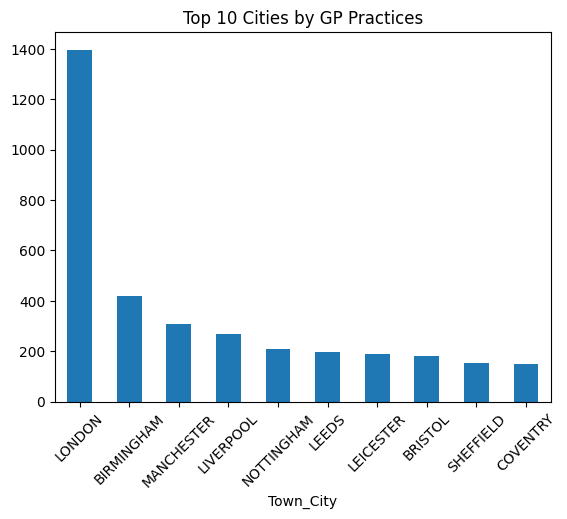

In [ ]:
import matplotlib.pyplot as plt

gp_clean["Town_City"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Cities by GP Practices")
plt.xticks(rotation=45)
plt.show()